# Advanced Climate and Flood Pattern Analysis in India (2010–2025)

## Relationship Analysis and Pattern Exploration

This notebook explores possible relationships between urban flood events and climate-related variables such as ENSO phase, antecedent rainfall, monsoon timing, and flood type distribution across India.

## Objectives

The objectives of this analysis are:

- Study flood event distribution across ENSO phases
- Analyze antecedent rainfall patterns associated with floods
- Examine flood occurrence relative to monsoon onset timing
- Explore state-wise flood vulnerability trends
- Identify possible climate and hydrological relationships

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

## Loading the Dataset

In [11]:
df = pd.read_excel("../data/India_Flood_Dataset_Final.xlsx")

In [12]:
df.head()

,DATE,YEAR,MONTH,STATE,CITY,LATITUDE,LONGITUDE,FLOOD_EVENT_NAME,FLOOD_TYPE,KERALA_MONSOON_ONSET,LOCAL_MONSOON_ONSET,DAYS_AFTER_KERALA_ONSET,ANTECEDENT_RAINFALL_MM,EL_NINO,LA_NINA,ENSO_PHASE,SOIL_MOISTURE,DATA_SOURCE
0,2010-07-25,2010,July,Maharashtra,Mumbai,19.076,72.877,Mumbai Urban Flooding 2010,Urban,2010-05-31,2010-06-12,55,325,No,Yes,Strong La Nina,High,News Archives / Wikipedia
1,2010-08-06,2010,August,Ladakh,Leh,34.152,77.577,Ladakh Flash Floods 2010,Flash,2010-05-31,2010-07-01,67,80,No,Yes,Strong La Nina,Moderate,NIDM 2025
2,2010-09-18,2010,September,Odisha,Bhubaneswar,20.296,85.824,Odisha Floods 2010,Riverine,2010-05-31,2010-06-12,110,205,No,Yes,Strong La Nina,High,NIDM 2025
3,2010-07-15,2010,July,Uttar Pradesh,Lucknow,26.846,80.946,Uttar Pradesh Floods 2010,Riverine,2010-05-31,2010-06-20,45,210,No,Yes,Strong La Nina,High,NIDM 2025
4,2010-06-15,2010,June,Assam,Guwahati,26.144,91.736,Assam Floods 2010,Riverine,2010-05-31,2010-06-05,15,340,No,Yes,Strong La Nina,Moderate,NDMA / NIDM 2025


## ENSO Phase and Flood Event Analysis

In [13]:
df["ENSO_PHASE"].value_counts()

ENSO_PHASE
Moderate La Nina       29
Strong La Nina         17
Neutral                14
Moderate El Nino       12
Weak La Nina           12
Weak El Nino            8
Very Strong El Nino     5
Name: count, dtype: int64

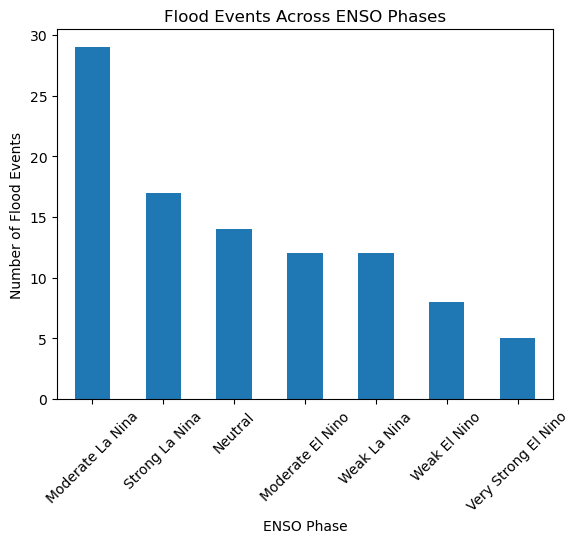

In [14]:
df["ENSO_PHASE"].value_counts().plot(kind="bar")

plt.title("Flood Events Across ENSO Phases")
plt.xlabel("ENSO Phase")
plt.ylabel("Number of Flood Events")

plt.xticks(rotation=45)

plt.show()

### Observation

Flood events are distributed across multiple ENSO phases. This suggests that large-scale climate oscillations may influence rainfall variability and urban flood occurrence patterns in India.

## Antecedent Rainfall Analysis

In [15]:
df["ANTECEDENT_RAINFALL_MM"].describe()

count     97.000000
mean     247.701031
std      128.036548
min       65.000000
25%      165.000000
50%      220.000000
75%      300.000000
max      850.000000
Name: ANTECEDENT_RAINFALL_MM, dtype: float64

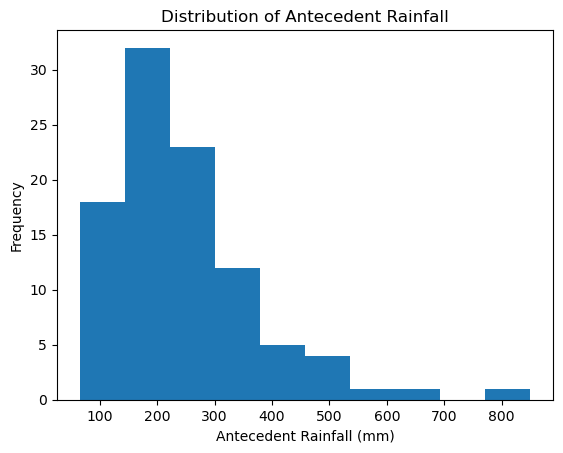

In [16]:
df["ANTECEDENT_RAINFALL_MM"].plot(kind="hist", bins=10)

plt.title("Distribution of Antecedent Rainfall")
plt.xlabel("Antecedent Rainfall (mm)")
plt.ylabel("Frequency")

plt.show()

### Observation

Several flood events are associated with high antecedent rainfall values, indicating the importance of accumulated rainfall prior to urban flood occurrence.

## Flood Timing Relative to Kerala Monsoon Onset

In [17]:
df["DAYS_AFTER_KERALA_ONSET"].describe()

count     97.000000
mean      53.309278
std       42.146659
min     -116.000000
25%       23.000000
50%       52.000000
75%       74.000000
max      182.000000
Name: DAYS_AFTER_KERALA_ONSET, dtype: float64

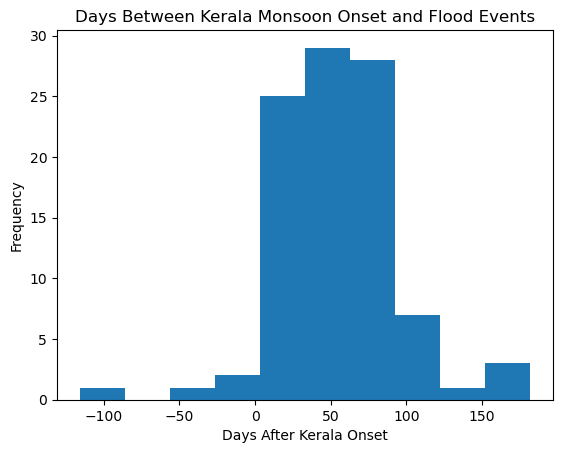

In [18]:
df["DAYS_AFTER_KERALA_ONSET"].plot(kind="hist", bins=10)

plt.title("Days Between Kerala Monsoon Onset and Flood Events")
plt.xlabel("Days After Kerala Onset")
plt.ylabel("Frequency")

plt.show()

### Observation

Many flood events occur within a limited time window after Kerala monsoon onset, suggesting a seasonal clustering of urban flood events during active monsoon progression.

## Flood Type and Antecedent Rainfall Relationship

In [19]:
df.groupby("FLOOD_TYPE")["ANTECEDENT_RAINFALL_MM"].mean()

FLOOD_TYPE
Cyclonic    122.500000
Flash       278.437500
GLOF         65.000000
Riverine    222.852459
Urban       333.411765
Name: ANTECEDENT_RAINFALL_MM, dtype: float64

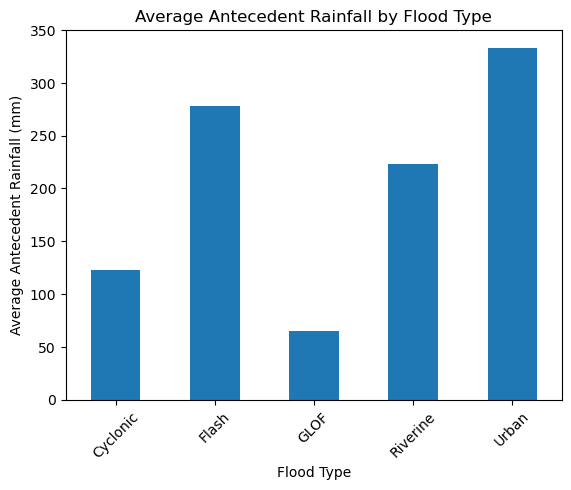

In [20]:
df.groupby("FLOOD_TYPE")["ANTECEDENT_RAINFALL_MM"].mean().plot(kind="bar")

plt.title("Average Antecedent Rainfall by Flood Type")
plt.xlabel("Flood Type")
plt.ylabel("Average Antecedent Rainfall (mm)")

plt.xticks(rotation=45)

plt.show()

### Observation

Different flood types exhibit varying average antecedent rainfall levels, indicating that rainfall accumulation patterns may influence flood characteristics.

## State Vulnerability Analysis

In [21]:
df["STATE"].value_counts().head(10)

STATE
Assam               17
Maharashtra         11
Gujarat              8
Odisha               7
Bihar                7
Uttarakhand          5
West Bengal          5
Uttar Pradesh        5
Kerala               4
Himachal Pradesh     4
Name: count, dtype: int64

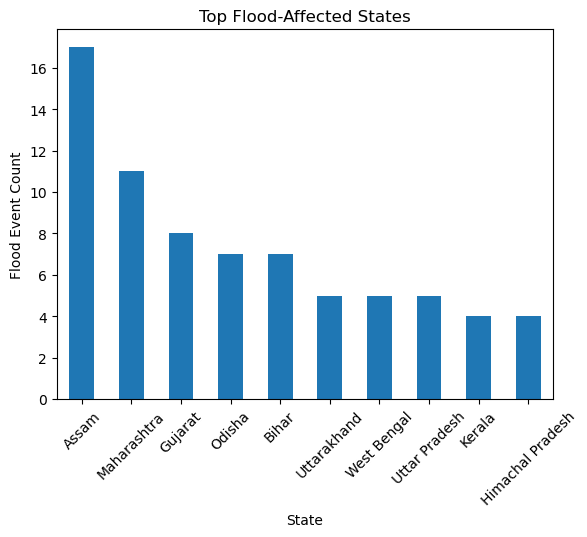

In [22]:
df["STATE"].value_counts().head(10).plot(kind="bar")

plt.title("Top Flood-Affected States")
plt.xlabel("State")
plt.ylabel("Flood Event Count")

plt.xticks(rotation=45)

plt.show()

### Observation

Some states experience repeated urban flood events over multiple years, suggesting persistent hydrological and urban vulnerability patterns.

## Urban Flood Concentration Across Cities

In [23]:
df["CITY"].value_counts().head(10)

CITY
Guwahati       16
Mumbai          9
Bhubaneswar     7
Patna           7
Kolkata         5
Lucknow         5
Shimla          4
Vadodara        4
Kochi           3
Dehradun        3
Name: count, dtype: int64

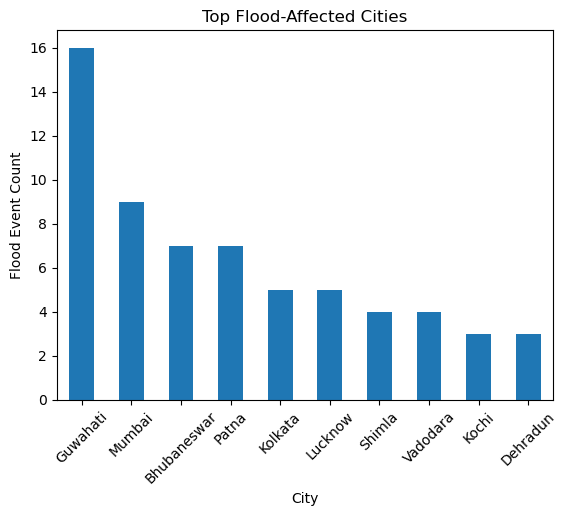

In [24]:
df["CITY"].value_counts().head(10).plot(kind="bar")

plt.title("Top Flood-Affected Cities")
plt.xlabel("City")
plt.ylabel("Flood Event Count")

plt.xticks(rotation=45)

plt.show()

### Observation

Major metropolitan regions appear repeatedly in flood event records, indicating increasing urban flood exposure in densely populated cities.

## Correlation Analysis

In [25]:
numeric_columns = [
    "YEAR",
    "ANTECEDENT_RAINFALL_MM",
    "DAYS_AFTER_KERALA_ONSET"
]

df[numeric_columns].corr()

,YEAR,ANTECEDENT_RAINFALL_MM,DAYS_AFTER_KERALA_ONSET
YEAR,1.000000,-0.051432,-0.172274
ANTECEDENT_RAINFALL_MM,-0.051432,1.000000,0.318923
DAYS_AFTER_KERALA_ONSET,-0.172274,0.318923,1.000000


### Observation

The correlation matrix provides a preliminary understanding of relationships between temporal and hydrological variables associated with urban flood events.

## Key Insights

- Urban flood events are concentrated during monsoon months.
- Certain states and cities show repeated flood occurrence patterns.
- Antecedent rainfall appears strongly associated with flood events.
- Flood occurrence patterns vary across ENSO phases.
- Flood events tend to cluster within a limited period after Kerala monsoon onset.
- Urban flooding is increasingly concentrated in major metropolitan regions.

## Conclusion

This analysis explored climate-related and hydrological relationships associated with urban flood events in India between 2010 and 2025.

The results indicate that monsoon progression, antecedent rainfall, ENSO variability, and regional concentration patterns may all contribute to urban flood occurrence.

The analytical framework developed in this study can support future work involving advanced statistical analysis, spatial flood mapping, and machine learning-based flood susceptibility assessment.